In [1]:
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
plt.rcParams["figure.figsize"]= (10,8)
plt.rcParams["figure.dpi"]= 150
plt.rcParams["font.size"]= 15


In [3]:
X = np.array([i for i in range(16)]).reshape(-1, 1)
noise_std_dev = 0.5 # Standard deviation of the noise

np.random.seed(40)
noise = np.random.normal(loc=0, scale=noise_std_dev, size=X.shape)
y = X + noise

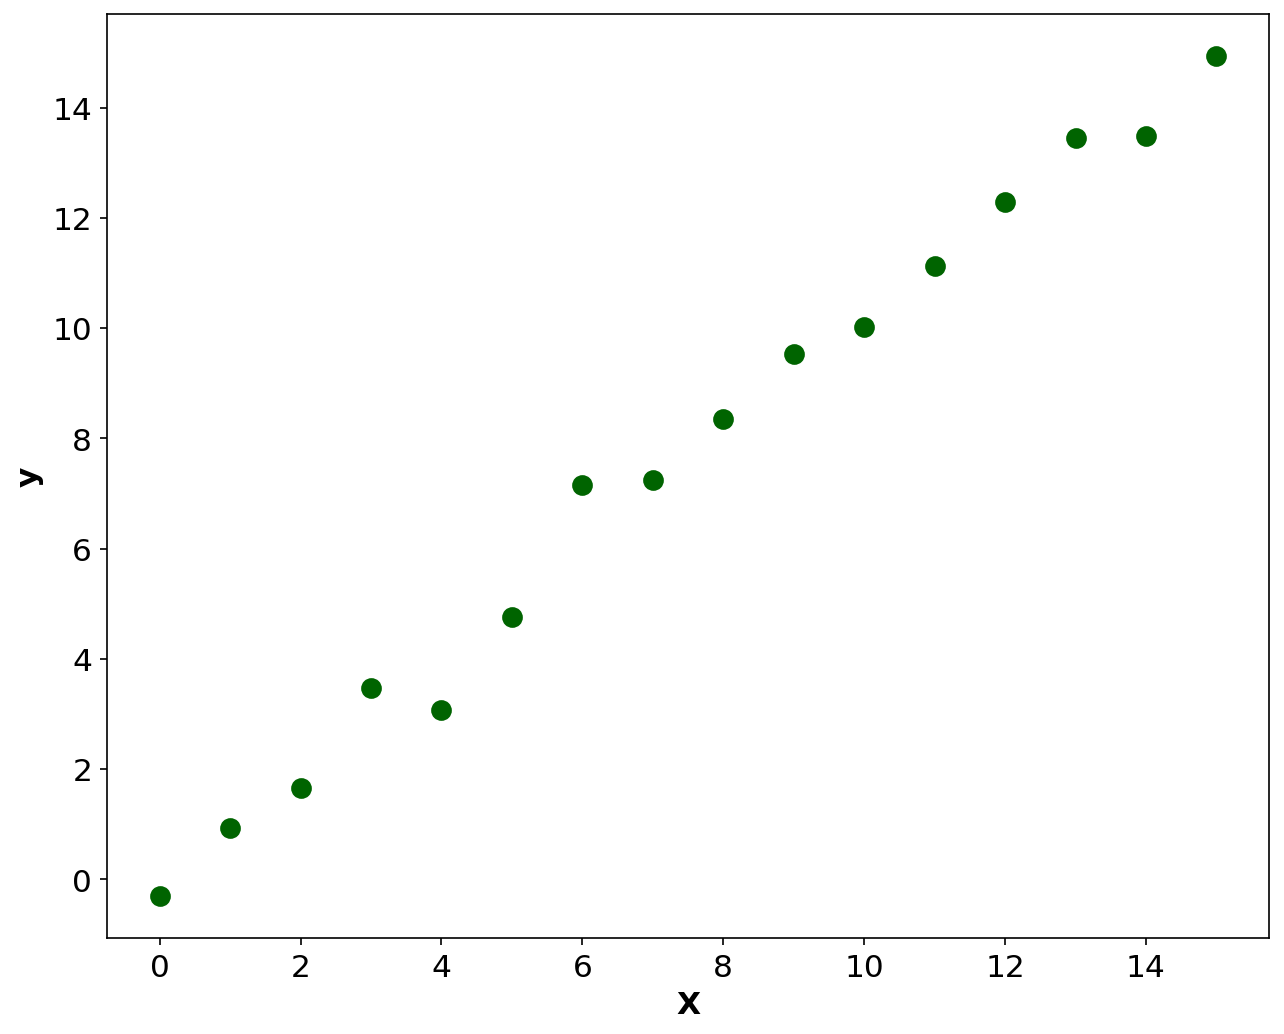

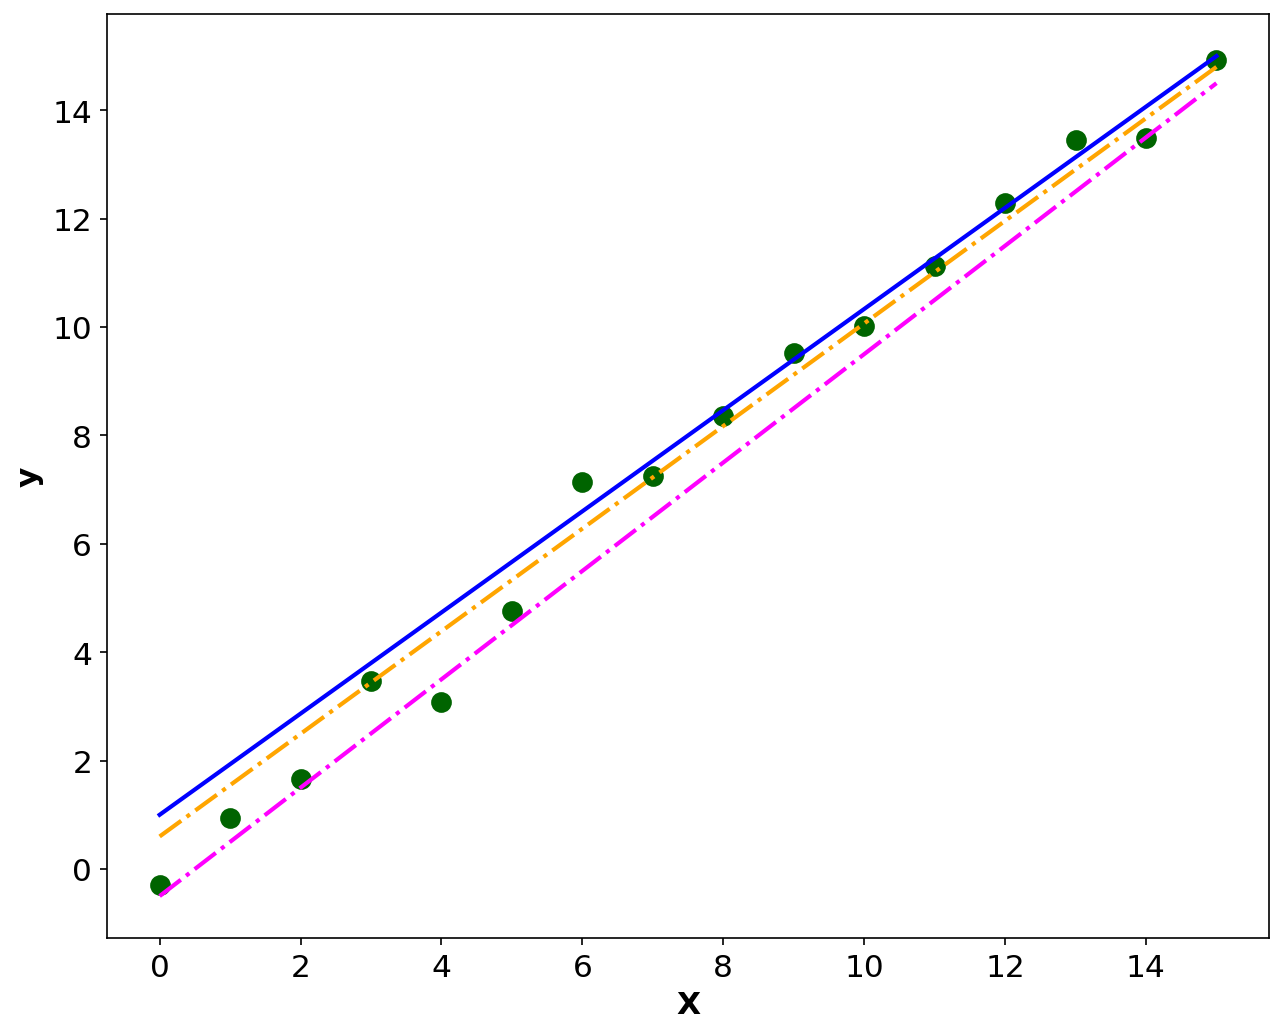

In [4]:
X_b = np.c_[np.ones((len(X), 1)), X]

plt.scatter(X, y, color='darkgreen', s=80)
plt.xlabel('X', fontweight='bold')
plt.ylabel('y', fontweight='bold')
plt.show()

plt.scatter(X, y, color='darkgreen', s=80)
plt.plot([0, 15], [0.6, 14.8], linestyle="-.", color="orange", lw=2)
plt.plot([0, 15], [-0.5, 14.5], linestyle="-.", color="magenta", lw=2)
plt.plot([0, 15], [1, 15], linestyle="-", color="blue", lw=2)
plt.xlabel('X', fontweight='bold')
plt.ylabel('y', fontweight='bold')
plt.show()

In [5]:
def compute_cost(theta,X,y):
    n=len(y)
    predictions= X.dot(theta)
    cost= (1/(2*n)) * np.sum((predictions-y)**2)
    return cost

def compute_gradient(theta,X,y):
    n=len(y)
    predictions= X.dot(theta)
    gradient= (1/n) * X.T.dot(predictions-y)
    return gradient

def gradient_descent(X,y,theta,learning_rate,num_iterations):
    cost_history = []
    theta_history= []

    for i in range(num_iterations): 
        gradients = compute_gradient(theta,X,y)
        theta = theta - learning_rate * gradients
        cost = compute_cost (theta,X,y)
        cost_history.append(cost)
        theta_history.append(theta.copy())
    
    return theta,cost_history, theta_history 

Text(0.5, 1.0, 'Linear Regression Fit')

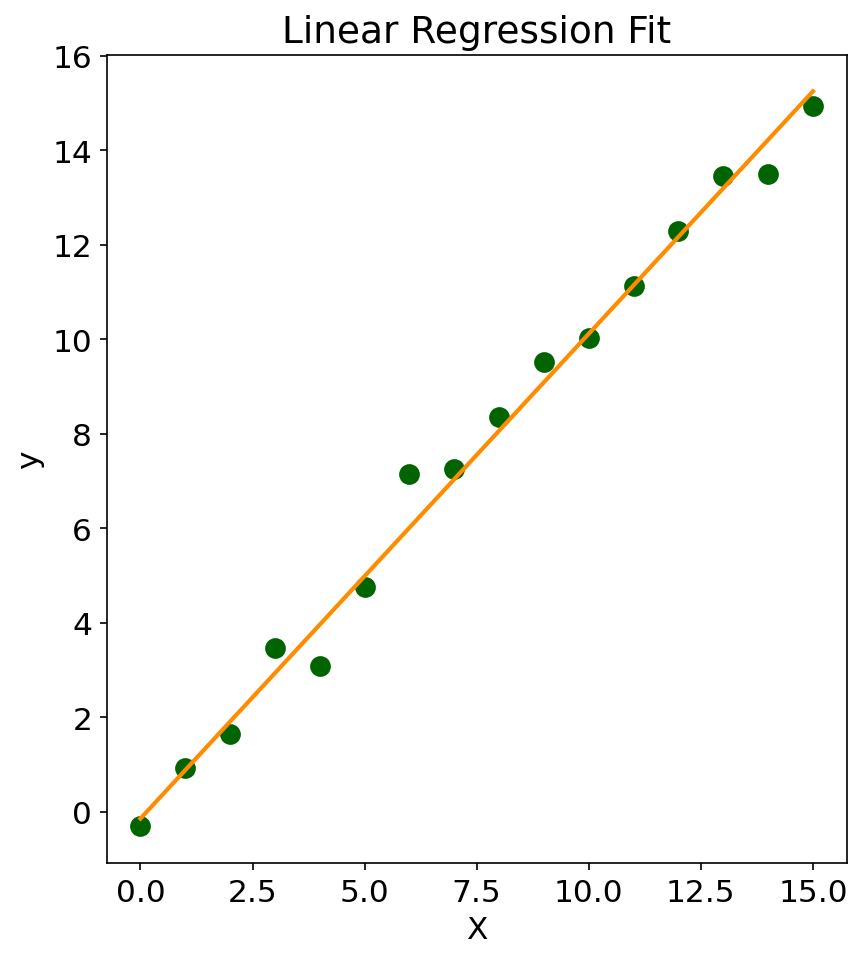

In [6]:


#%% Parameters for gradient descent
theta_initial = np.random.randn(2, 1)
learning_rate = 0.01 # (alpha)
num_iterations = 500 # (epochs)

#%% Perform gradient descent
theta, cost_history, theta_history = gradient_descent(X_b, y, theta_initial, learning_rate, num_iterations)

#%% Plot the data and the linear regression fit
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.scatter(X, y, color='darkgreen', s=80)
te = X_b.dot(theta)
plt.plot(X, X_b.dot(theta), color="darkorange", linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')

In [7]:
#%% Plot the data and the linear regression fit



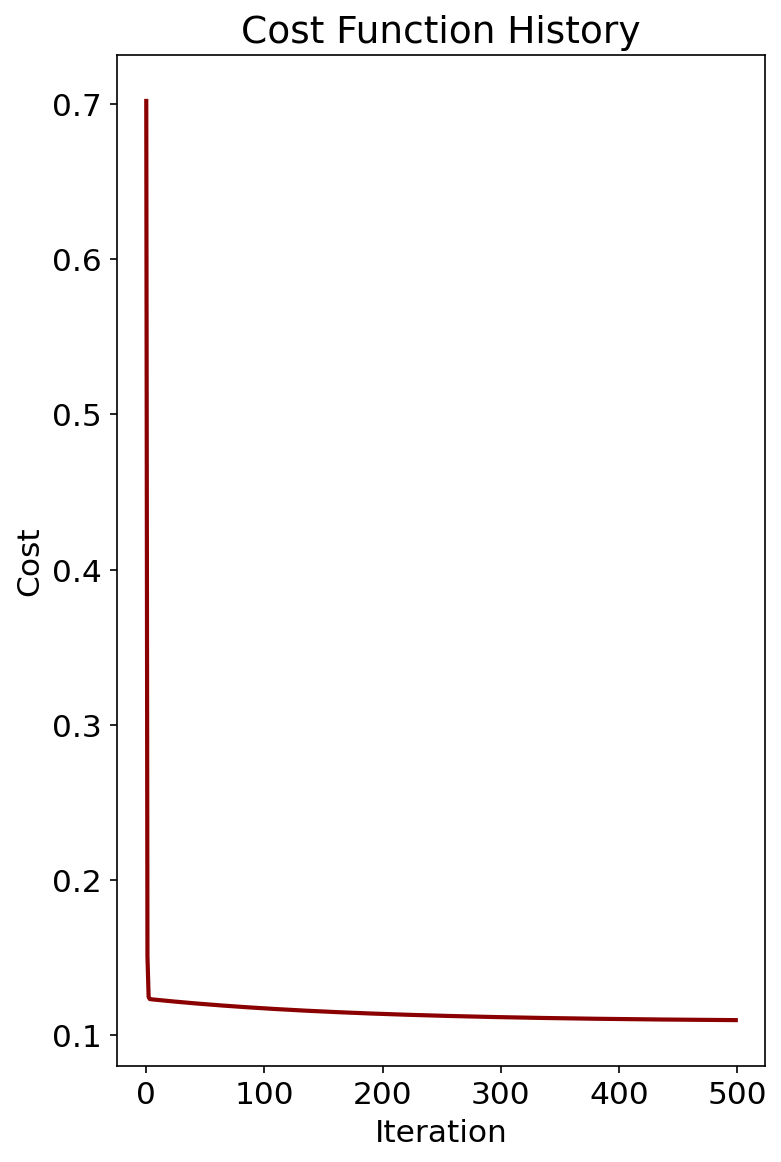

In [8]:
# Plot the cost function history
plt.subplot(1, 2, 2)
plt.plot(range(num_iterations), cost_history, color="darkred", lw=2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function History')

plt.tight_layout()
plt.show()



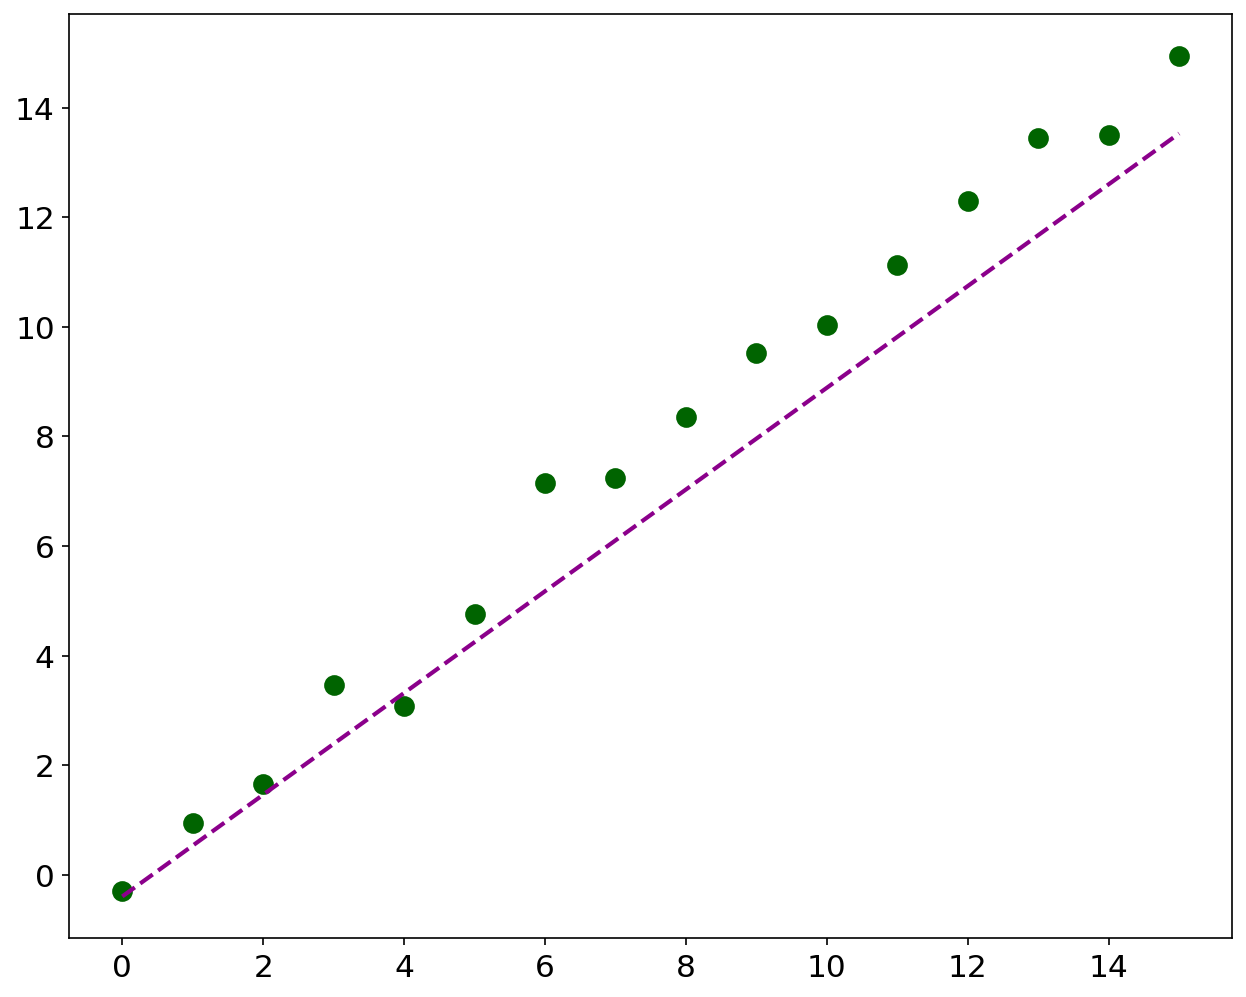

In [9]:
#%% Plot the cost function
plt.scatter(X, y, color='darkgreen', s=80)
plt.plot(X, X_b.dot(theta_history[0]), linestyle="--", color="darkmagenta",
         linewidth=2, label="epochs (0)")